# Redes Neuronales — Clasificación Dicotómica (Diabetes)

[![francomansilla.com](https://img.shields.io/badge/francomansilla.com-555555?style=flat&logo=globe&logoColor=white)](https://www.francomansilla.com)

Este notebook entrena y compara distintas arquitecturas de redes neuronales (MLP) para predecir si un paciente tiene diabetes (variable binaria: 0/1). Se escalan los datos con `StandardScaler`, se exploran activaciones y tamaños de capa progresivamente, y se optimizan los hiperparámetros con `GridSearchCV`. Al final se entrena el modelo ganador con todos los datos y se generan predicciones en casos nuevos.

<br>

**Librerías**

[![Pandas](https://img.shields.io/badge/Pandas-150458?style=flat&logo=pandas&logoColor=white)](https://pandas.pydata.org/docs/)
[![NumPy](https://img.shields.io/badge/NumPy-013243?style=flat&logo=numpy&logoColor=white)](https://numpy.org/doc/)
[![Matplotlib](https://img.shields.io/badge/Matplotlib-11557c?style=flat&logo=python&logoColor=white)](https://matplotlib.org/stable/index.html)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-F7931E?style=flat&logo=scikit-learn&logoColor=white)](https://scikit-learn.org/stable/)

**Modelos y métodos**

[![MLPClassifier](https://img.shields.io/badge/MLPClassifier-0078D4?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
[![Pipeline](https://img.shields.io/badge/Pipeline-6A0DAD?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
[![GridSearchCV](https://img.shields.io/badge/GridSearchCV-E34F26?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
[![StandardScaler](https://img.shields.io/badge/StandardScaler-2E8B57?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

**Métricas**

[![Accuracy](https://img.shields.io/badge/Accuracy-DC143C?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
[![F1](https://img.shields.io/badge/F1_Score-B8860B?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
[![ROC-AUC](https://img.shields.io/badge/ROC--AUC-228B22?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)

---


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.pipeline import Pipeline


In [7]:
df = pd.read_csv('https://raw.githubusercontent.com/fmansillaib/umayor_class/main/datasets/datos_transversales_paneles/diabetes/datos.csv')
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,11,95.4,65.7,16.0,29.3,37.1,0.056,80,0
1,8,115.5,48.5,5.5,21.9,36.5,0.454,81,0
2,13,159.9,83.2,34.9,89.6,32.7,0.155,45,0
3,4,93.3,61.9,15.7,97.0,32.6,0.357,68,0
4,6,152.1,62.1,25.1,-15.1,31.2,0.523,78,0
...,...,...,...,...,...,...,...,...,...
763,10,99.8,77.8,35.0,101.4,38.3,0.776,23,1
764,14,116.2,65.3,30.5,132.8,35.0,0.057,50,1
765,14,138.9,65.6,46.0,-112.0,37.4,0.661,24,1
766,8,148.2,60.8,5.1,155.8,28.0,0.480,69,1


In [8]:
df_entrenamiento, df_validacion = train_test_split(df, test_size=0.30, random_state=42, stratify=df['Outcome'])
df_entrenamiento = df_entrenamiento.reset_index(drop=True)
df_validacion    = df_validacion.reset_index(drop=True)

print(f"Entrenamiento: {len(df_entrenamiento)} filas")
print(f"Validación:    {len(df_validacion)} filas")
print(f"\nDistribución Outcome — Entrenamiento:\n{df_entrenamiento['Outcome'].value_counts()}")
print(f"\nDistribución Outcome — Validación:\n{df_validacion['Outcome'].value_counts()}")


Entrenamiento: 537 filas
Validación:    231 filas

Distribución Outcome — Entrenamiento:
Outcome
0    350
1    187
Name: count, dtype: int64

Distribución Outcome — Validación:
Outcome
0    150
1     81
Name: count, dtype: int64


# Análisis Preliminar

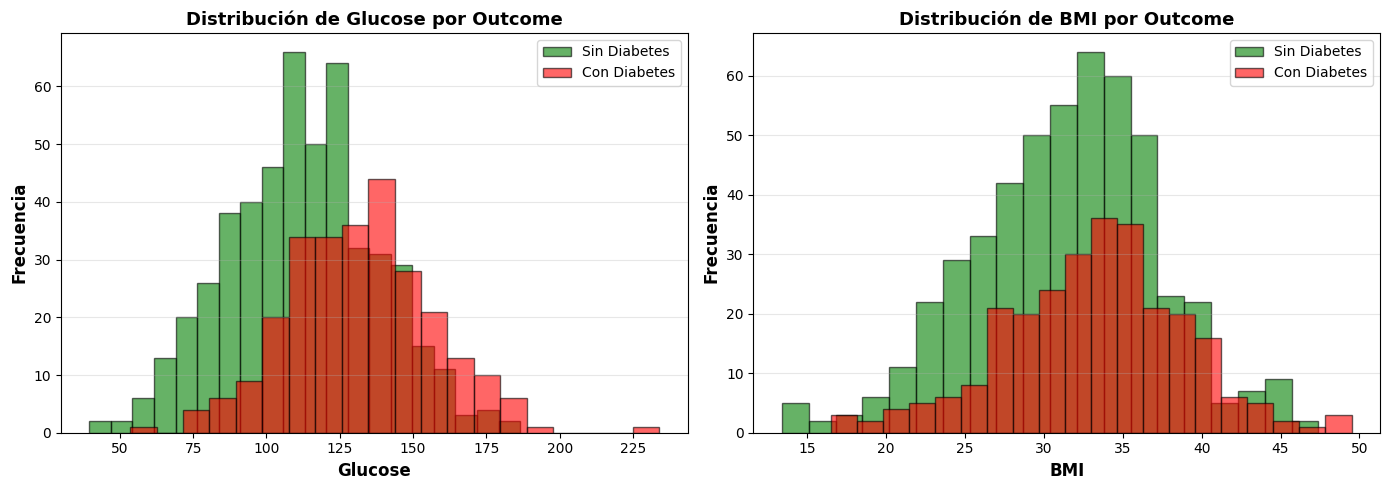

In [21]:
# Histogramas de las variables más predictivas de Outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Glucose
axes[0].hist(df[df['Outcome'] == 0]['Glucose'], bins=20, alpha=0.6, label='Sin Diabetes', color='green', edgecolor='black')
axes[0].hist(df[df['Outcome'] == 1]['Glucose'], bins=20, alpha=0.6, label='Con Diabetes', color='red', edgecolor='black')
axes[0].set_xlabel('Glucose', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Glucose por Outcome', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# BMI
axes[1].hist(df[df['Outcome'] == 0]['BMI'], bins=20, alpha=0.6, label='Sin Diabetes', color='green', edgecolor='black')
axes[1].hist(df[df['Outcome'] == 1]['BMI'], bins=20, alpha=0.6, label='Con Diabetes', color='red', edgecolor='black')
axes[1].set_xlabel('BMI', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución de BMI por Outcome', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Red Neuronal Clasificadora (MLP)

Una red neuronal recibe variables de entrada, las procesa en capas de neuronas y entrega una probabilidad de pertenecer a cada clase. Se escalan los datos antes de entrenar porque las redes son sensibles a diferencias de magnitud entre variables.


In [9]:
warnings.filterwarnings('ignore', category=ConvergenceWarning)

target   = 'Outcome'
features = [c for c in df.columns if c != target]

X_train = df_entrenamiento[features]
y_train = df_entrenamiento[target]
X_val   = df_validacion[features]
y_val   = df_validacion[target]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)


### Una sola neurona — activación logística


In [10]:
m = MLPClassifier(hidden_layer_sizes=(1,), activation='logistic', max_iter=500, random_state=42)
m.fit(X_train_sc, y_train)
y_p = m.predict(X_val_sc)
print(f"Accuracy : {accuracy_score(y_val, y_p)*100:.2f}%")
print(f"F1       : {f1_score(y_val, y_p):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, m.predict_proba(X_val_sc)[:,1]):.4f}")


Accuracy : 71.43%
F1       : 0.5417
ROC-AUC  : 0.7688


### Dos neuronas — cambiando la función de activación


In [11]:
for activacion in ['logistic', 'relu', 'tanh']:
    m = MLPClassifier(hidden_layer_sizes=(2,), activation=activacion, max_iter=500, random_state=42)
    m.fit(X_train_sc, y_train)
    y_p = m.predict(X_val_sc)
    print(f"{activacion:10s} → Accuracy: {accuracy_score(y_val, y_p)*100:.2f}%  F1: {f1_score(y_val, y_p):.4f}  ROC-AUC: {roc_auc_score(y_val, m.predict_proba(X_val_sc)[:,1]):.4f}")


logistic   → Accuracy: 71.00%  F1: 0.4962  ROC-AUC: 0.7681
relu       → Accuracy: 71.86%  F1: 0.5695  ROC-AUC: 0.7531
tanh       → Accuracy: 71.86%  F1: 0.5517  ROC-AUC: 0.7543


### Dos capas con 2 neuronas — cambiando la función de activación


In [12]:
for activacion in ['logistic', 'relu', 'tanh']:
    m = MLPClassifier(hidden_layer_sizes=(2, 2), activation=activacion, max_iter=500, random_state=42)
    m.fit(X_train_sc, y_train)
    y_p = m.predict(X_val_sc)
    print(f"{activacion:10s} → Accuracy: {accuracy_score(y_val, y_p)*100:.2f}%  F1: {f1_score(y_val, y_p):.4f}  ROC-AUC: {roc_auc_score(y_val, m.predict_proba(X_val_sc)[:,1]):.4f}")


logistic   → Accuracy: 64.94%  F1: 0.0000  ROC-AUC: 0.5925
relu       → Accuracy: 64.94%  F1: 0.0000  ROC-AUC: 0.4938
tanh       → Accuracy: 71.43%  F1: 0.6071  ROC-AUC: 0.7626


### Multilayer Perceptron — pocas capas y pocas neuronas


In [13]:
arquitecturas = {
    "1 capa  (4)":       (4,),
    "2 capas (4, 4)":    (4, 4),
    "3 capas (4, 4, 4)": (4, 4, 4),
}

for nombre, capas in arquitecturas.items():
    m = MLPClassifier(hidden_layer_sizes=capas, activation='relu', max_iter=500, random_state=42)
    m.fit(X_train_sc, y_train)
    y_p = m.predict(X_val_sc)
    print(f"{nombre:22s} → Accuracy: {accuracy_score(y_val, y_p)*100:.2f}%  F1: {f1_score(y_val, y_p):.4f}  ROC-AUC: {roc_auc_score(y_val, m.predict_proba(X_val_sc)[:,1]):.4f}")


1 capa  (4)            → Accuracy: 71.00%  F1: 0.5939  ROC-AUC: 0.7530
2 capas (4, 4)         → Accuracy: 71.00%  F1: 0.5315  ROC-AUC: 0.7648
3 capas (4, 4, 4)      → Accuracy: 72.73%  F1: 0.6087  ROC-AUC: 0.7549


### Tabla comparativa de todos los modelos


In [14]:
modelos_config = [
    ("1 neurona — logistic",       (1,),       'logistic'),
    ("2 neuronas — logistic",      (2,),       'logistic'),
    ("2 neuronas — relu",          (2,),       'relu'),
    ("2 neuronas — tanh",          (2,),       'tanh'),
    ("2 capas (2,2) — logistic",   (2, 2),     'logistic'),
    ("2 capas (2,2) — relu",       (2, 2),     'relu'),
    ("2 capas (2,2) — tanh",       (2, 2),     'tanh'),
    ("MLP 1 capa (4) — relu",      (4,),       'relu'),
    ("MLP 2 capas (4,4) — relu",   (4, 4),     'relu'),
    ("MLP 3 capas (4,4,4) — relu", (4, 4, 4), 'relu'),
]

resultados = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for nombre, capas, act in modelos_config:
        m = MLPClassifier(hidden_layer_sizes=capas, activation=act, max_iter=500, random_state=42)
        m.fit(X_train_sc, y_train)
        acc_train = accuracy_score(y_train, m.predict(X_train_sc)) * 100
        acc_val   = accuracy_score(y_val,   m.predict(X_val_sc))   * 100
        f1_train  = f1_score(y_train, m.predict(X_train_sc))
        f1_val    = f1_score(y_val,   m.predict(X_val_sc))
        auc_train = roc_auc_score(y_train, m.predict_proba(X_train_sc)[:,1])
        auc_val   = roc_auc_score(y_val,   m.predict_proba(X_val_sc)[:,1])
        resultados.append([nombre,
                           f"{acc_train:.2f}%", f"{acc_val:.2f}%",
                           f"{f1_train:.4f}",   f"{f1_val:.4f}",
                           f"{auc_train:.4f}",  f"{auc_val:.4f}"])

df_tabla = pd.DataFrame(resultados, columns=[
    "Modelo",
    "Accuracy Train", "Accuracy Val",
    "F1 Train", "F1 Val",
    "ROC-AUC Train", "ROC-AUC Val"
])
df_tabla


,Modelo,Accuracy Train,Accuracy Val,F1 Train,F1 Val,ROC-AUC Train,ROC-AUC Val
0,1 neurona — logistic,72.44%,71.43%,0.5316,0.5417,0.7787,0.7688
1,2 neuronas — logistic,72.44%,71.00%,0.5163,0.4962,0.7783,0.7681
2,2 neuronas — relu,73.00%,71.86%,0.5483,0.5695,0.7717,0.7531
3,2 neuronas — tanh,72.81%,71.86%,0.5466,0.5517,0.7789,0.7543
4,"2 capas (2,2) — logistic",65.18%,64.94%,0.0000,0.0000,0.5982,0.5925
5,"2 capas (2,2) — relu",65.18%,64.94%,0.0000,0.0000,0.4980,0.4938
6,"2 capas (2,2) — tanh",74.86%,71.43%,0.6176,0.6071,0.7816,0.7626
7,MLP 1 capa (4) — relu,73.93%,71.00%,0.5930,0.5939,0.7826,0.7530
8,"MLP 2 capas (4,4) — relu",73.74%,71.00%,0.5662,0.5315,0.7795,0.7648
9,"MLP 3 capas (4,4,4) — relu",74.67%,72.73%,0.6180,0.6087,0.8001,0.7549


### GridSearch — mejor modelo


In [15]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(4,), (8,), (4, 4), (8, 8)],
    'mlp__activation':         ['relu', 'tanh'],
    'mlp__alpha':              [0.0, 0.001],
}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    gs = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=5, n_jobs=1)
    gs.fit(X_train, y_train)

print("Mejores parámetros:")
for k, v in gs.best_params_.items():
    print(f"  {k}: {v}")

mejor = gs.best_estimator_
acc_train = accuracy_score(y_train, mejor.predict(X_train)) * 100
acc_val   = accuracy_score(y_val,   mejor.predict(X_val))   * 100
f1_train  = f1_score(y_train, mejor.predict(X_train))
f1_val    = f1_score(y_val,   mejor.predict(X_val))
auc_train = roc_auc_score(y_train, mejor.predict_proba(X_train)[:,1])
auc_val   = roc_auc_score(y_val,   mejor.predict_proba(X_val)[:,1])

print(f"\nAccuracy Train : {acc_train:.2f}%")
print(f"Accuracy Val   : {acc_val:.2f}%")
print(f"F1 Train       : {f1_train:.4f}")
print(f"F1 Val         : {f1_val:.4f}")
print(f"ROC-AUC Train  : {auc_train:.4f}")
print(f"ROC-AUC Val    : {auc_val:.4f}")


Mejores parámetros:
  mlp__activation: relu
  mlp__alpha: 0.001
  mlp__hidden_layer_sizes: (4,)

Accuracy Train : 73.93%
Accuracy Val   : 71.00%
F1 Train       : 0.5930
F1 Val         : 0.5939
ROC-AUC Train  : 0.7826
ROC-AUC Val    : 0.7529


### Diagnóstico del mejor modelo — matriz de confusión y curva ROC


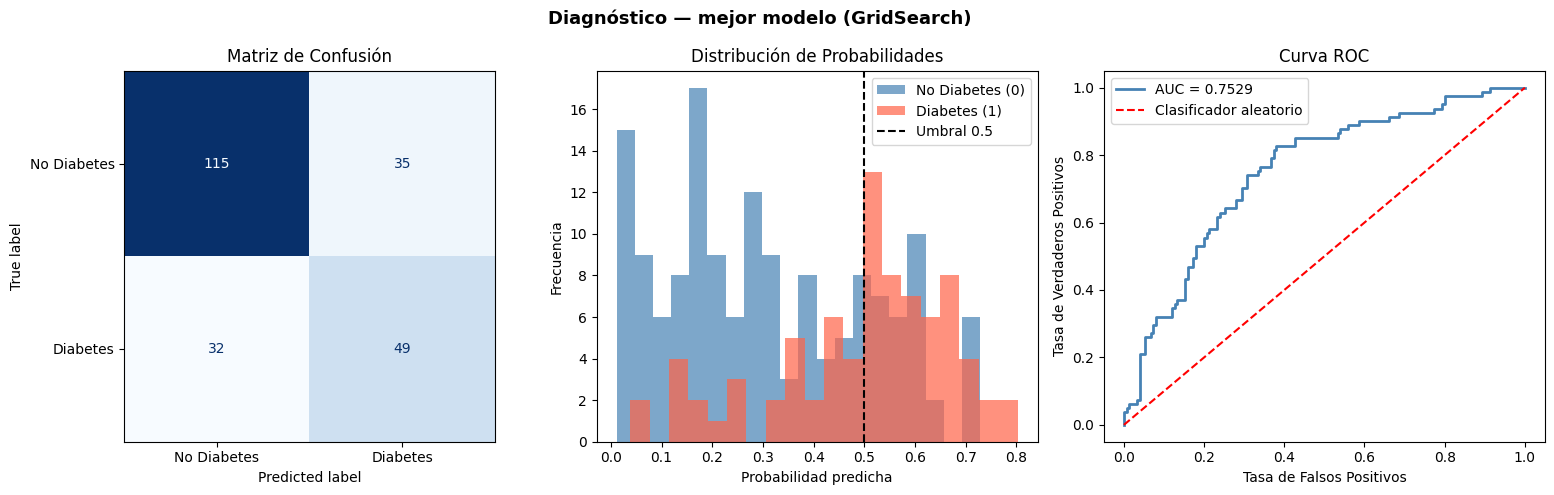

In [16]:
y_pred_val  = mejor.predict(X_val)
y_proba_val = mejor.predict_proba(X_val)[:,1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Matriz de Confusión ---
ax = axes[0]
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión')

# --- 2. Distribución de probabilidades predichas ---
ax = axes[1]
ax.hist(y_proba_val[y_val == 0], bins=20, alpha=0.7, color='steelblue', label='No Diabetes (0)')
ax.hist(y_proba_val[y_val == 1], bins=20, alpha=0.7, color='tomato',    label='Diabetes (1)')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Umbral 0.5')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Probabilidades')
ax.legend()

# --- 3. Curva ROC ---
ax = axes[2]
fpr, tpr, _ = roc_curve(y_val, y_proba_val)
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc_val:.4f}')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC')
ax.legend()

plt.suptitle('Diagnóstico — mejor modelo (GridSearch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Modelo final — entrenado con todos los datos


In [17]:
X_todo = df[features]
y_todo = df[target]

mejor_params = gs.best_params_
modelo_final = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=mejor_params['mlp__hidden_layer_sizes'],
        activation=mejor_params['mlp__activation'],
        alpha=mejor_params['mlp__alpha'],
        max_iter=1000,
        random_state=42
    ))
])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    modelo_final.fit(X_todo, y_todo)

y_pred_todo  = modelo_final.predict(X_todo)
y_proba_todo = modelo_final.predict_proba(X_todo)[:,1]

print(f"Accuracy (todos los datos) : {accuracy_score(y_todo, y_pred_todo)*100:.2f}%")
print(f"F1       (todos los datos) : {f1_score(y_todo, y_pred_todo):.4f}")
print(f"ROC-AUC  (todos los datos) : {roc_auc_score(y_todo, y_proba_todo):.4f}")
print(f"N                          : {len(y_todo)}")


Accuracy (todos los datos) : 73.18%
F1       (todos los datos) : 0.5880
ROC-AUC  (todos los datos) : 0.7758
N                          : 768


### Predicción en casos nuevos


In [18]:
# Columnas: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
casos_nuevos = pd.DataFrame([
    {"Pregnancies": 1,  "Glucose": 85,  "BloodPressure": 66, "SkinThickness": 29, "Insulin": 0,   "BMI": 26.6, "DiabetesPedigreeFunction": 0.351, "Age": 31},  # joven sano
    {"Pregnancies": 8,  "Glucose": 183, "BloodPressure": 64, "SkinThickness": 0,  "Insulin": 0,   "BMI": 23.3, "DiabetesPedigreeFunction": 0.672, "Age": 32},  # glucosa muy alta
    {"Pregnancies": 0,  "Glucose": 137, "BloodPressure": 40, "SkinThickness": 35, "Insulin": 168, "BMI": 43.1, "DiabetesPedigreeFunction": 2.288, "Age": 33},  # obesidad + historial
    {"Pregnancies": 5,  "Glucose": 116, "BloodPressure": 74, "SkinThickness": 0,  "Insulin": 0,   "BMI": 25.6, "DiabetesPedigreeFunction": 0.201, "Age": 30},  # perfil moderado
    {"Pregnancies": 10, "Glucose": 168, "BloodPressure": 74, "SkinThickness": 0,  "Insulin": 0,   "BMI": 38.0, "DiabetesPedigreeFunction": 0.537, "Age": 34},  # múltiples embarazos
])

proba = modelo_final.predict_proba(casos_nuevos)[:,1]
pred  = modelo_final.predict(casos_nuevos)

casos_nuevos['P(Diabetes)'] = proba.round(3)
casos_nuevos['Diagnóstico'] = ['Diabetes' if p == 1 else 'No Diabetes' for p in pred]
casos_nuevos.index = [f"Caso {i+1}" for i in range(len(casos_nuevos))]
casos_nuevos[['Pregnancies', 'Glucose', 'BMI', 'Age', 'P(Diabetes)', 'Diagnóstico']]


,Pregnancies,Glucose,BMI,Age,P(Diabetes),Diagnóstico
Caso 1,1,85,26.6,31,0.033,No Diabetes
Caso 2,8,183,23.3,32,0.451,No Diabetes
Caso 3,0,137,43.1,33,0.744,Diabetes
Caso 4,5,116,25.6,30,0.049,No Diabetes
Caso 5,10,168,38.0,34,0.540,Diabetes
